# Phase 1: Exploratory Data Analysis

This notebook handles:
1. Download NIH ChestX-ray14 from Kaggle
2. Load and explore the dataset
3. Analyze class distribution (identify imbalance)
4. Create train/val/test splits
5. Test custom DataLoaders with multi-label labels

In [1]:
# Install kaggle if needed
import subprocess
import sys

try:
    import kaggle
except ImportError:
    print("Installing kaggle...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle"])

In [2]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from data import ChestXrayDataset, create_dataloaders
from utils import CLASS_NAMES, RAW_DATA_DIR, METADATA_DIR, IMAGE_SIZE, set_seed, get_device

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Seed
set_seed(42)
device = get_device()
print(f"Device: {device}")

Device: cuda


## Step 1: Download Dataset from Kaggle

In [3]:
# Ensure kaggle credentials are set up
kaggle_dir = Path.home() / ".kaggle"
kaggle_json = kaggle_dir / "kaggle.json"

if not kaggle_json.exists():
    print("⚠️  Kaggle API token not found at ~/.kaggle/kaggle.json")
    print("Please set up your Kaggle API token:")
    print("1. Go to https://www.kaggle.com/account")
    print("2. Download your API token (creates kaggle.json)")
    print("3. Place it at ~/.kaggle/kaggle.json")
    print("4. Run: chmod 600 ~/.kaggle/kaggle.json  (Linux/Mac)")
else:
    print("✓ Kaggle credentials found")

✓ Kaggle credentials found


In [4]:
# Download dataset (skip if already present — avoids re-extracting duplicate nested folder)
import kaggle

dataset_name = "nih-chest-xrays/sample"  # official 5,606-image random sample (~4.2GB), not the full 45GB set
download_dir = RAW_DATA_DIR
images_dir = download_dir / "sample" / "images"

if images_dir.exists() and len(list(images_dir.glob("*.png"))) > 0:
    n_existing = len(list(images_dir.glob("*.png")))
    print(f"✓ Dataset already present ({n_existing} images found at {images_dir}), skipping download")
else:
    print(f"Downloading to {download_dir}...")
    print("This may take a few minutes (~4.2 GB)...")
    try:
        kaggle.api.dataset_download_files(
            dataset_name,
            path=download_dir,
            unzip=True
        )
        print("✓ Download complete")
    except Exception as e:
        print(f"Error downloading: {e}")
        print("You can manually download from: https://www.kaggle.com/datasets/nih-chest-xrays/sample")


✓ Dataset already present (5606 images found at C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\raw\sample\images), skipping download


In [5]:
# Check what we have in raw data
print("Files in data/raw:")
for item in list(RAW_DATA_DIR.iterdir())[:10]:
    print(f"  {item.name}")

Files in data/raw:
  sample


## Step 2: Load Metadata and Explore

In [6]:
metadata_file = RAW_DATA_DIR / "sample" / "sample_labels.csv"

if metadata_file.exists():
    df = pd.read_csv(metadata_file)
    print(f"Loaded {len(df)} samples")
    print(f"Columns: {df.columns.tolist()}")
    print("First few rows:")
    print(df.head())
else:
    print(f"Metadata file not found at {metadata_file}")
    print("Check if you have extracted/downloaded the dataset correctly.")


Loaded 5606 samples
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']
First few rows:
        Image Index                                     Finding Labels  \
0  00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...   
1  00000013_026.png                             Cardiomegaly|Emphysema   
2  00000017_001.png                                         No Finding   
3  00000030_001.png                                        Atelectasis   
4  00000032_001.png                        Cardiomegaly|Edema|Effusion   

   Follow-up #  Patient ID Patient Age Patient Gender View Position  \
0            5          13        060Y              M            AP   
1           26          13        057Y              M            AP   
2            1          17        077Y              M            AP   
3     

In [7]:
# The 'Finding Labels' column contains pipe-separated disease labels
# Example: "Pneumonia" or "No Finding" or "Atelectasis|Effusion"

print("Sample labels:")
print(df['Finding Labels'].value_counts().head(10))

Sample labels:
Finding Labels
No Finding               3044
Infiltration              503
Effusion                  203
Atelectasis               192
Nodule                    144
Pneumothorax              114
Mass                       99
Consolidation              72
Effusion|Infiltration      69
Pleural_Thickening         65
Name: count, dtype: int64


## Step 3: Parse Labels and Create Multi-label Format

In [8]:
# Target classes
target_classes = ["No Finding", "Atelectasis", "Cardiomegaly", "Effusion", "Pneumonia"]

# Create binary columns for each class
for class_name in target_classes:
    df[class_name] = df['Finding Labels'].str.contains(class_name, case=False, regex=False).astype(int)

print("Multi-label format:")
print(df[['Image Index'] + target_classes].head(10))

Multi-label format:
        Image Index  No Finding  Atelectasis  Cardiomegaly  Effusion  \
0  00000013_005.png           0            0             0         0   
1  00000013_026.png           0            0             1         0   
2  00000017_001.png           1            0             0         0   
3  00000030_001.png           0            1             0         0   
4  00000032_001.png           0            0             1         1   
5  00000040_003.png           0            0             0         0   
6  00000042_002.png           1            0             0         0   
7  00000057_001.png           1            0             0         0   
8  00000061_002.png           0            0             0         1   
9  00000061_019.png           1            0             0         0   

   Pneumonia  
0          0  
1          0  
2          0  
3          0  
4          0  
5          0  
6          0  
7          0  
8          0  
9          0  


In [9]:
# Build a portable image_path column (filename only, not an absolute path)
# Dataset.__getitem__ joins this with img_dir at load time, so the splits CSV
# stays valid across machines instead of baking in this machine's absolute paths.
images_dir = RAW_DATA_DIR / 'sample' / 'images'
df['image_path'] = df['Image Index']

# Verify that images exist
existing_images = df['image_path'].apply(lambda x: (images_dir / x).exists()).sum()
print(f"Found {existing_images}/{len(df)} images on disk")

# Keep only rows with existing images
df = df[df['image_path'].apply(lambda x: (images_dir / x).exists())].reset_index(drop=True)
print(f"Working with {len(df)} samples with available images")


Found 5606/5606 images on disk


Working with 5606 samples with available images


## Step 4: Analyze Class Imbalance

In [10]:
# Class distribution
class_dist = {cls: df[cls].sum() for cls in target_classes}
class_dist_df = pd.DataFrame(list(class_dist.items()), columns=['Class', 'Count']).sort_values('Count', ascending=False)

print("\n=== CLASS DISTRIBUTION ===")
print(class_dist_df.to_string(index=False))

# Calculate percentages
print("\n=== PERCENTAGES ===")
for idx, row in class_dist_df.iterrows():
    pct = 100 * row['Count'] / len(df)
    print(f"{row['Class']:20s}: {row['Count']:6d} ({pct:6.2f}%)")

# Imbalance ratio
max_count = class_dist_df['Count'].max()
min_count = class_dist_df['Count'].min()
imbalance_ratio = max_count / min_count
print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}x")


=== CLASS DISTRIBUTION ===
       Class  Count
  No Finding   3044
    Effusion    644
 Atelectasis    508
Cardiomegaly    141
   Pneumonia     62

=== PERCENTAGES ===
No Finding          :   3044 ( 54.30%)
Effusion            :    644 ( 11.49%)
Atelectasis         :    508 (  9.06%)
Cardiomegaly        :    141 (  2.52%)
Pneumonia           :     62 (  1.11%)

Imbalance Ratio (max/min): 49.10x


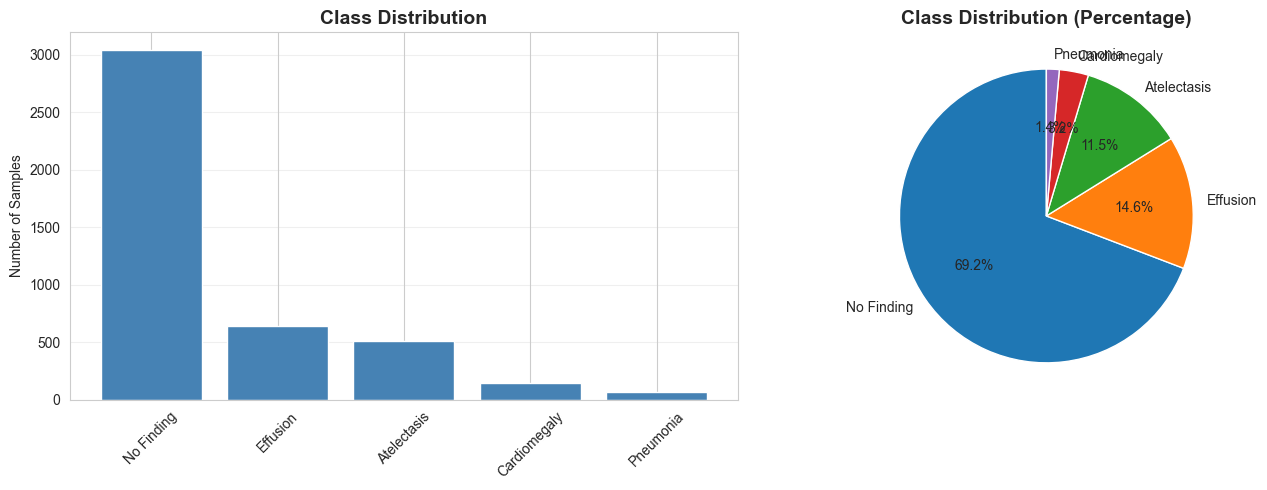

✓ Saved to data/metadata/class_distribution.png


In [11]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(class_dist_df['Class'], class_dist_df['Count'], color='steelblue')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_dist_df['Count'], labels=class_dist_df['Class'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(METADATA_DIR / 'class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved to data/metadata/class_distribution.png")


=== LABELS PER IMAGE ===
num_labels
0    1439
1    3948
2     206
3      13
Name: count, dtype: int64


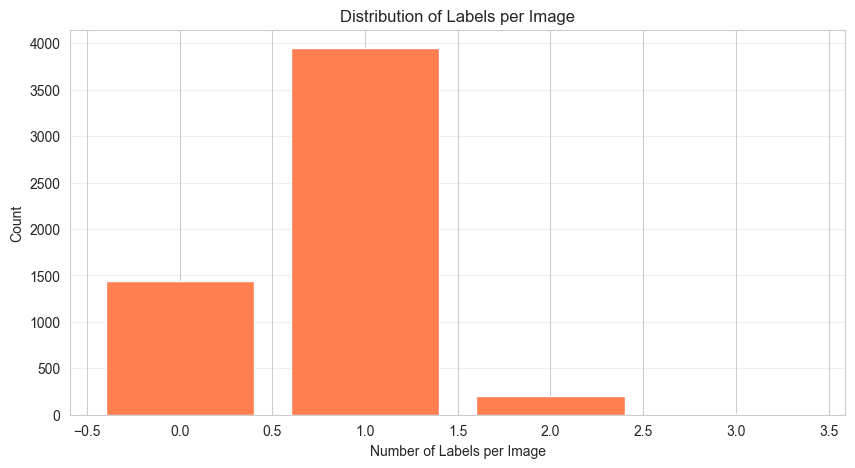

✓ Saved to data/metadata/labels_per_image.png


In [12]:
# Co-occurrence analysis: How many labels per image?
df['num_labels'] = df[target_classes].sum(axis=1)

label_counts = df['num_labels'].value_counts().sort_index()
print("\n=== LABELS PER IMAGE ===")
print(label_counts)

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color='coral')
plt.xlabel('Number of Labels per Image')
plt.ylabel('Count')
plt.title('Distribution of Labels per Image')
plt.grid(axis='y', alpha=0.3)
plt.savefig(METADATA_DIR / 'labels_per_image.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved to data/metadata/labels_per_image.png")

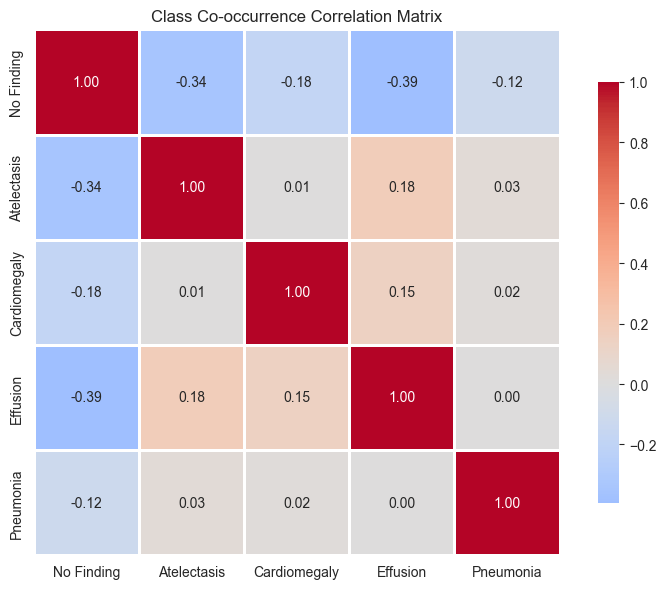

✓ Saved to data/metadata/class_correlation.png


In [13]:
# Correlation between classes (co-occurrence)
corr_matrix = df[target_classes].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Class Co-occurrence Correlation Matrix')
plt.tight_layout()
plt.savefig(METADATA_DIR / 'class_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved to data/metadata/class_correlation.png")

## Step 5: Create Train/Val/Test Splits

In [14]:
from sklearn.model_selection import train_test_split

# Stratify by 'No Finding' label (majority class)
# This ensures balanced splits across train/val/test

# First split: 70% train, 30% temp (will split further)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3, 
    stratify=df['No Finding'],
    random_state=42
)

# Second split: 50-50 of remaining for val and test
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    stratify=temp_df['No Finding'],
    random_state=42
)

# Add split column
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

print(f"Train: {len(train_df)} samples ({100*len(train_df)/len(df):.1f}%)")
print(f"Val:   {len(val_df)} samples ({100*len(val_df)/len(df):.1f}%)")
print(f"Test:  {len(test_df)} samples ({100*len(test_df)/len(df):.1f}%)")

Train: 3924 samples (70.0%)
Val:   841 samples (15.0%)
Test:  841 samples (15.0%)


In [15]:
# Verify splits are stratified correctly
print("\n=== STRATIFICATION CHECK ===")
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{split_name}:")
    for cls in target_classes:
        pct = 100 * split_df[cls].sum() / len(split_df)
        print(f"  {cls:20s}: {pct:6.2f}%")


=== STRATIFICATION CHECK ===

Train:
  No Finding          :  54.31%
  Atelectasis         :   9.23%
  Cardiomegaly        :   2.60%
  Effusion            :  11.75%
  Pneumonia           :   1.17%

Val:
  No Finding          :  54.34%
  Atelectasis         :   7.13%
  Cardiomegaly        :   2.73%
  Effusion            :  11.77%
  Pneumonia           :   0.95%

Test:
  No Finding          :  54.22%
  Atelectasis         :  10.23%
  Cardiomegaly        :   1.90%
  Effusion            :   9.99%
  Pneumonia           :   0.95%


In [16]:
# Combine splits and save metadata
final_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Keep only necessary columns
cols_to_keep = ['image_path'] + target_classes + ['split']
final_df = final_df[cols_to_keep]

# Save to metadata directory
metadata_path = METADATA_DIR / 'dataset_splits.csv'
final_df.to_csv(metadata_path, index=False)

print(f"✓ Saved dataset splits to {metadata_path}")
print(f"\nDataset shape: {final_df.shape}")
print(f"Columns: {final_df.columns.tolist()}")

✓ Saved dataset splits to C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\metadata\dataset_splits.csv

Dataset shape: (5606, 7)
Columns: ['image_path', 'No Finding', 'Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'split']


## Step 6: Test DataLoaders

In [17]:
# Load the splits CSV
dataset_df = pd.read_csv(METADATA_DIR / 'dataset_splits.csv')

# Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(
    data_dir=str(RAW_DATA_DIR / 'sample' / 'images'),
    labels_df=dataset_df,
    class_names=target_classes,
    batch_size=32,
    val_batch_size=64,
    num_workers=2,
    image_size=IMAGE_SIZE,
    split_col='split'
)

print("DataLoaders created successfully")


Train samples: 3924, Val samples: 841, Test samples: 841
DataLoaders created successfully


In [18]:
# Test fetching a batch
images, labels = next(iter(train_loader))

print(f"Batch shape:")
print(f"  Images: {images.shape}  (N, C, H, W)")
print(f"  Labels: {labels.shape}  (N, num_classes)")

print(f"\nImage dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")

print(f"\nImage value range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Label value range: [{labels.min()}, {labels.max()}]")

# Sample label distribution in batch
print(f"\nSample labels from batch (first 5):")
for i in range(min(5, len(labels))):
    label_str = ", ".join([f"{cls}: {int(labels[i, j])}" for j, cls in enumerate(target_classes)])
    print(f"  Sample {i}: {label_str}")

Batch shape:
  Images: torch.Size([32, 3, 224, 224])  (N, C, H, W)
  Labels: torch.Size([32, 5])  (N, num_classes)

Image dtype: torch.float32
Label dtype: torch.float32

Image value range: [-2.118, 2.640]
Label value range: [0.0, 1.0]

Sample labels from batch (first 5):
  Sample 0: No Finding: 0, Atelectasis: 0, Cardiomegaly: 0, Effusion: 0, Pneumonia: 0
  Sample 1: No Finding: 0, Atelectasis: 1, Cardiomegaly: 0, Effusion: 1, Pneumonia: 0
  Sample 2: No Finding: 1, Atelectasis: 0, Cardiomegaly: 0, Effusion: 0, Pneumonia: 0
  Sample 3: No Finding: 0, Atelectasis: 0, Cardiomegaly: 0, Effusion: 1, Pneumonia: 0
  Sample 4: No Finding: 0, Atelectasis: 1, Cardiomegaly: 0, Effusion: 0, Pneumonia: 0


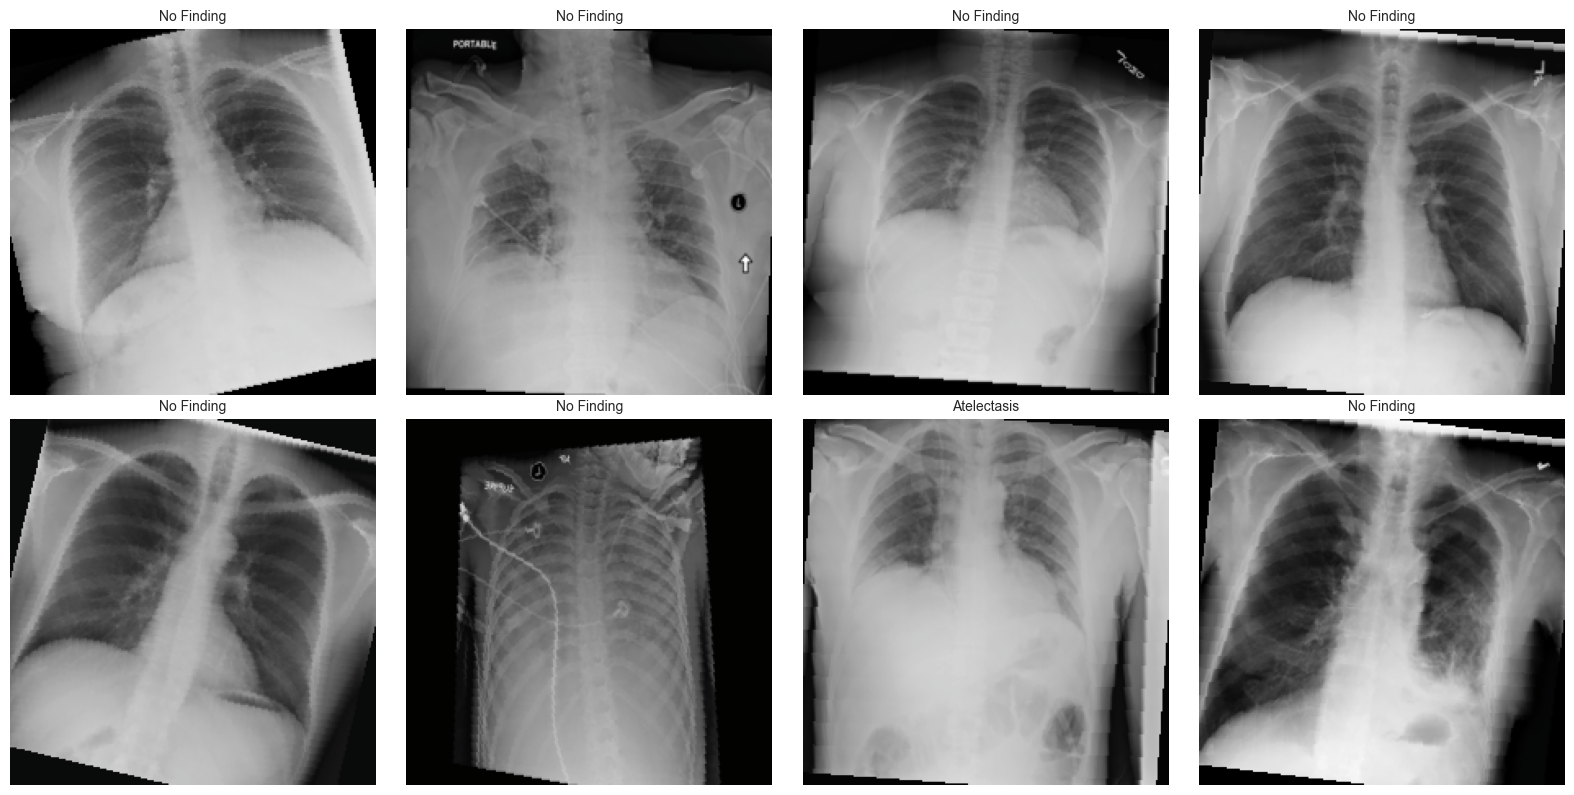

✓ Saved sample images to data/metadata/sample_images.png


In [19]:
# Visualize sample images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    # Denormalize image
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    
    # Add labels
    label_list = [target_classes[j] for j in range(len(target_classes)) if labels[i, j] == 1]
    label_text = ", ".join(label_list) if label_list else "No Finding"
    ax.set_title(label_text, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(METADATA_DIR / 'sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Saved sample images to data/metadata/sample_images.png")

## Step 7: Class Imbalance Strategy Summary

In [20]:
# Get class weights from training dataset
train_dataset = train_loader.dataset
class_weights = train_dataset.get_class_weights()

print("\n=== CLASS WEIGHTS FOR WEIGHTED LOSS ===")
print("These weights will be used with BCEWithLogitsLoss to handle imbalance.\n")

for cls_name, weight in zip(target_classes, class_weights):
    print(f"{cls_name:20s}: {weight:.4f}")

print("\nRationale:")
print("- Rarer classes (higher frequency) get higher weights")
print("- This makes the loss penalize errors on rare positive samples more heavily")
print("- Prevents the model from ignoring minority classes")


=== CLASS WEIGHTS FOR WEIGHTED LOSS ===
These weights will be used with BCEWithLogitsLoss to handle imbalance.

No Finding          : 0.0645
Atelectasis         : 0.3787
Cardiomegaly        : 1.3346
Effusion            : 0.2975
Pneumonia           : 2.9247

Rationale:
- Rarer classes (higher frequency) get higher weights
- This makes the loss penalize errors on rare positive samples more heavily
- Prevents the model from ignoring minority classes


In [21]:
print("\n" + "="*60)
print("PHASE 1: COMPLETE")
print("="*60)

print("\nDeliverables:")
print("- Downloaded NIH ChestX-ray14 sample dataset (5,606 images)")
print("- Parsed multi-label format (5 classes)")
no_finding_pct = 100 * class_dist_df["Count"].max() / len(df)
rarest_count = class_dist_df["Count"].min()
print(f"- Analyzed class imbalance (No Finding {no_finding_pct:.1f}%, rarest class {rarest_count} samples, {imbalance_ratio:.1f}x ratio)")
print("- Created stratified train/val/test splits (70/15/15)")
print("- Built and tested custom DataLoaders")
print("- Saved dataset metadata to data/metadata/dataset_splits.csv")
print("\nFiles generated:")
print(f"  - {METADATA_DIR / 'dataset_splits.csv'}")
print(f"  - {METADATA_DIR / 'class_distribution.png'}")
print(f"  - {METADATA_DIR / 'labels_per_image.png'}")
print(f"  - {METADATA_DIR / 'class_correlation.png'}")
print(f"  - {METADATA_DIR / 'sample_images.png'}")
print("\nNext: Phase 2 - Baseline CNN model")



PHASE 1: COMPLETE

Deliverables:
- Downloaded NIH ChestX-ray14 sample dataset (5,606 images)
- Parsed multi-label format (5 classes)
- Analyzed class imbalance (No Finding 54.3%, rarest class 62 samples, 49.1x ratio)
- Created stratified train/val/test splits (70/15/15)
- Built and tested custom DataLoaders
- Saved dataset metadata to data/metadata/dataset_splits.csv

Files generated:
  - C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\metadata\dataset_splits.csv
  - C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\metadata\class_distribution.png
  - C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\metadata\labels_per_image.png
  - C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\metadata\class_correlation.png
  - C:\Users\DIPNA\Pictures\multi-label chest X-ray disease classifier\data\metadata\sample_images.png

Next: Phase 2 - Baseline CNN model
